## Veri Önişleme

  ### Eksik Veri (Data ınmputation)

In [1]:
import pandas as pd
import numpy as np

In [2]:
sozluk = {'İsim':pd.Series(['Ada','Cem','Sibel','Ahmet','Mehmet','Ali','Veli','Ayşe','Hüseyin','Necmi','Nalan','Namık']),
          'Meslek':pd.Series(['işçi','işçi','memur','serbest','serbest',None,None,'sigortacı','İşsiz',None,None,'memur']),
          'Tarih':pd.Series(['05.06.2024','03.02.2023','03.02.2023','11.12.2020','11.12.2020',None,None,
            None,'03.02.2023',None,'11.12.2020','11.12.2020']),
         'Yaş':pd.Series([21, 24, 25, 44, 31, 27, 35, 33, 42, 29, 41, 43]),
         'ÇocukSayısı':pd.Series([None, None, None, None, None, 1, 2, 0, None, None, None, None,]),
         'Puan':pd.Series([89, 87, 77, 55, 70, 79, 73, 79, 54, 92, 61, 69])}
df = pd.DataFrame(sozluk)
print(df)

       İsim     Meslek       Tarih  Yaş  ÇocukSayısı  Puan
0       Ada       işçi  05.06.2024   21          NaN    89
1       Cem       işçi  03.02.2023   24          NaN    87
2     Sibel      memur  03.02.2023   25          NaN    77
3     Ahmet    serbest  11.12.2020   44          NaN    55
4    Mehmet    serbest  11.12.2020   31          NaN    70
5       Ali       None        None   27          1.0    79
6      Veli       None        None   35          2.0    73
7      Ayşe  sigortacı        None   33          0.0    79
8   Hüseyin      İşsiz  03.02.2023   42          NaN    54
9     Necmi       None        None   29          NaN    92
10    Nalan       None  11.12.2020   41          NaN    61
11    Namık      memur  11.12.2020   43          NaN    69


In [3]:
df.isnull().sum().sum() #Tüm tabloda toplam kaç Nan değer var?

17

In [4]:
df.isnull().sum() #özniteliklerin değer almadığı kaç satır var?

İsim           0
Meslek         4
Tarih          4
Yaş            0
ÇocukSayısı    9
Puan           0
dtype: int64

In [5]:
def eksik_deger_tablosu(df):
    eksik_deger = df.isnull().sum()
    eksik_deger_yuzde = 100 * df.isnull().sum()/len(df)
    eksik_deger_tablo = pd.concat([eksik_deger, eksik_deger_yuzde], axis=1)
    eksik_deger_tablo_son = eksik_deger_tablo.rename(
    columns = {0 : 'Eksik Degerler', 1 : '% Degeri'})
    return eksik_deger_tablo_son
eksik_deger_tablosu(df)

,Eksik Degerler,% Degeri
İsim,0,0.000000
Meslek,4,33.333333
Tarih,4,33.333333
Yaş,0,0.000000
ÇocukSayısı,9,75.000000
Puan,0,0.000000


In [6]:
tr = len(df) * .3  #yüzde 30 un altında kalanları siliyor. Yüzde 70 eksik değeri olanlar siliniyor
df.dropna(thresh = tr, axis = 1, inplace = True)
df

,İsim,Meslek,Tarih,Yaş,Puan
0,Ada,işçi,05.06.2024,21,89
1,Cem,işçi,03.02.2023,24,87
2,Sibel,memur,03.02.2023,25,77
3,Ahmet,serbest,11.12.2020,44,55
4,Mehmet,serbest,11.12.2020,31,70
5,Ali,None,None,27,79
6,Veli,None,None,35,73
7,Ayşe,sigortacı,None,33,79
8,Hüseyin,İşsiz,03.02.2023,42,54
9,Necmi,None,None,29,92


Meslek ve Tarih öznitelikleri için farklı eksik değer doldurma stratejileri izlenebilir. Örneğin, Meslek özniteliği olmayan kayıtlara 
"Diğer" değeri atanabilir. Tarih özniteliği eksik olan kayıtlar, Tarih kolonundaki

In [7]:
#Meslek özniteliğindeki Null değerleri 'Diğer' değeri ile doldur
df['Meslek'] = df['Meslek'].fillna('Diğer')

#Tarih özniteliğindeki Null değerleri Tarih benzersiz değerlerden ilki ile doldur
print(df['Tarih'].unique()[0])
df['Tarih'] = df['Tarih'].fillna(df['Tarih'].unique()[0])
df

05.06.2024


,İsim,Meslek,Tarih,Yaş,Puan
0,Ada,işçi,05.06.2024,21,89
1,Cem,işçi,03.02.2023,24,87
2,Sibel,memur,03.02.2023,25,77
3,Ahmet,serbest,11.12.2020,44,55
4,Mehmet,serbest,11.12.2020,31,70
5,Ali,Diğer,05.06.2024,27,79
6,Veli,Diğer,05.06.2024,35,73
7,Ayşe,sigortacı,05.06.2024,33,79
8,Hüseyin,İşsiz,03.02.2023,42,54
9,Necmi,Diğer,05.06.2024,29,92


Geçti isimli yeni bir öznitelik oluşturuldu ve sınavdan 70 ve üzerinde not alan kayıtların öznitelik değerleri "True" olarak ayarlanmıştır.

In [9]:
def basari_durumu(puan):
    return(puan >= 70)
df['Gecti'] = df['Puan'].apply(basari_durumu)
#df['Gecti'] = df['Puan'] > 70
df

,İsim,Meslek,Tarih,Yaş,Puan,Gecti
0,Ada,işçi,05.06.2024,21,89,True
1,Cem,işçi,03.02.2023,24,87,True
2,Sibel,memur,03.02.2023,25,77,True
3,Ahmet,serbest,11.12.2020,44,55,False
4,Mehmet,serbest,11.12.2020,31,70,True
5,Ali,Diğer,05.06.2024,27,79,True
6,Veli,Diğer,05.06.2024,35,73,True
7,Ayşe,sigortacı,05.06.2024,33,79,True
8,Hüseyin,İşsiz,03.02.2023,42,54,False
9,Necmi,Diğer,05.06.2024,29,92,True


In [14]:
df['Tarih']  = pd.to_datetime(df['Tarih']) # yıl sütunu ekledik tarih yılını yazdırdık
df['Yıl'] =df['Tarih'].dt.year
df

,İsim,Meslek,Tarih,Yaş,Puan,Gecti,Yıl
0,Ada,işçi,2024-05-06,21,89,True,2024
1,Cem,işçi,2023-03-02,24,87,True,2023
2,Sibel,memur,2023-03-02,25,77,True,2023
3,Ahmet,serbest,2020-11-12,44,55,False,2020
4,Mehmet,serbest,2020-11-12,31,70,True,2020
5,Ali,Diğer,2024-05-06,27,79,True,2024
6,Veli,Diğer,2024-05-06,35,73,True,2024
7,Ayşe,sigortacı,2024-05-06,33,79,True,2024
8,Hüseyin,İşsiz,2023-03-02,42,54,False,2023
9,Necmi,Diğer,2024-05-06,29,92,True,2024


--> Kategorik değerleri dönüştürme (Label\One-HotEncoding)

Label Encoder

In [18]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
df['Geçti'] = label_encoder.fit_transform(df['Gecti'])
df['Meslek'] = label_encoder.fit_transform(df['Meslek'])
df

,İsim,Meslek,Tarih,Yaş,Puan,Gecti,Yıl,Geçti
0,Ada,1,2024-05-06,21,89,True,2024,1
1,Cem,1,2023-03-02,24,87,True,2023,1
2,Sibel,2,2023-03-02,25,77,True,2023,1
3,Ahmet,3,2020-11-12,44,55,False,2020,0
4,Mehmet,3,2020-11-12,31,70,True,2020,1
5,Ali,0,2024-05-06,27,79,True,2024,1
6,Veli,0,2024-05-06,35,73,True,2024,1
7,Ayşe,4,2024-05-06,33,79,True,2024,1
8,Hüseyin,5,2023-03-02,42,54,False,2023,0
9,Necmi,0,2024-05-06,29,92,True,2024,1


In [22]:
x = df[['Puan']].values.astype(float)

#ölçeklendirme için minmaxscaler fonksiyonunu kullanıyoruz
#ölçeklendirme işleminde verinin (range)ni aralağını değiştiriken normalize etmede verinin dağılımını normal bir dağılım olarak değştiriyoruz
#MinMax
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
df['Puan2'] = pd.DataFrame(x_scaled)
df

,İsim,Meslek,Tarih,Yaş,Puan,Gecti,Yıl,Geçti,Puan2
0,Ada,1,2024-05-06,21,89,True,2024,1,0.921053
1,Cem,1,2023-03-02,24,87,True,2023,1,0.868421
2,Sibel,2,2023-03-02,25,77,True,2023,1,0.605263
3,Ahmet,3,2020-11-12,44,55,False,2020,0,0.026316
4,Mehmet,3,2020-11-12,31,70,True,2020,1,0.421053
5,Ali,0,2024-05-06,27,79,True,2024,1,0.657895
6,Veli,0,2024-05-06,35,73,True,2024,1,0.500000
7,Ayşe,4,2024-05-06,33,79,True,2024,1,0.657895
8,Hüseyin,5,2023-03-02,42,54,False,2023,0,0.000000
9,Necmi,0,2024-05-06,29,92,True,2024,1,1.000000


In [23]:
x = df[['Puan']].values.astype(float)

#ölçeklendirme için StandardScaler fonksiyonunu kullanıyoruz
min_max_scaler = preprocessing.StandardScaler() #MaxAbsScaler
x_scaled = min_max_scaler.fit_transform(x)
df['Puan3'] = pd.DataFrame(x_scaled)
df

,İsim,Meslek,Tarih,Yaş,Puan,Gecti,Yıl,Geçti,Puan2,Puan3
0,Ada,1,2024-05-06,21,89,True,2024,1,0.921053,1.263452
1,Cem,1,2023-03-02,24,87,True,2023,1,0.868421,1.097753
2,Sibel,2,2023-03-02,25,77,True,2023,1,0.605263,0.269260
3,Ahmet,3,2020-11-12,44,55,False,2020,0,0.026316,-1.553424
4,Mehmet,3,2020-11-12,31,70,True,2020,1,0.421053,-0.310685
5,Ali,0,2024-05-06,27,79,True,2024,1,0.657895,0.434959
6,Veli,0,2024-05-06,35,73,True,2024,1,0.500000,-0.062137
7,Ayşe,4,2024-05-06,33,79,True,2024,1,0.657895,0.434959
8,Hüseyin,5,2023-03-02,42,54,False,2023,0,0.000000,-1.636274
9,Necmi,0,2024-05-06,29,92,True,2024,1,1.000000,1.512000


## Performans Ölçütleri

Kapasite, Overfitting, Underfitting

<Figure size 800x600 with 0 Axes>

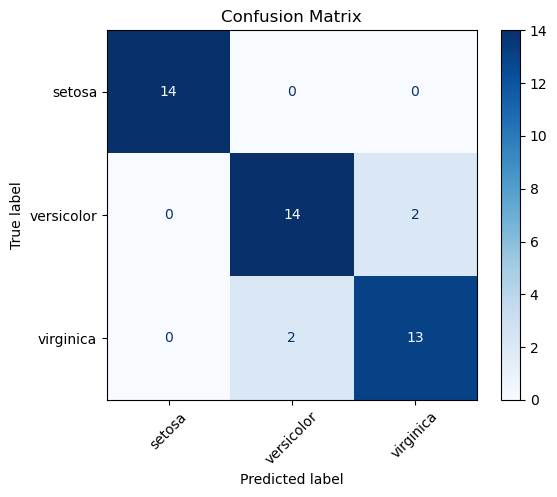

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm,datasets
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Çalışmak için veri seti yüklenmesi
iris=datasets.load_iris()
x=iris.data
y=iris.target 
#etiket bilgisi
class_names=iris.target_names

# Eğitim ve test veri kümelerini ayır
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

# Sınıflandırıcıyı çalıştır
classifier=svm.SVC(kernel="linear",C=.1).fit(x_train,y_train)

np.set_printoptions(precision=2)

# Test veri kümesi üzerinde tahminler yap
y_pred = classifier.predict(x_test)

# Karışıklık matrisini hesapla
cm = confusion_matrix(y_test,y_pred)

# Karışıklık matrisini görselleştir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)

plt.show()

In [49]:
print(x)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [50]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Data dosyasında çalışma

In [60]:
import pandas as pd
import numpy as np
data = pd.read_csv('data.csv') 
df.head()
df = data.copy()
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [61]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [65]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df.diagnosis = le.fit_transform(df['diagnosis'])

In [66]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [67]:
df.drop(["Unnamed: 32"], axis=1, inplace=True)

In [68]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [69]:
df.isnull().sum() #eksik değer var mı?

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [71]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=1)

In [78]:
clf = DecisionTreeClassifier()

In [79]:
clf = clf.fit(x_train,y_train)

In [80]:
y_pred = clf.predict(x_test)

In [81]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9415204678362573


In [82]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       108
           1       1.00      0.84      0.91        63

    accuracy                           0.94       171
   macro avg       0.96      0.92      0.93       171
weighted avg       0.95      0.94      0.94       171



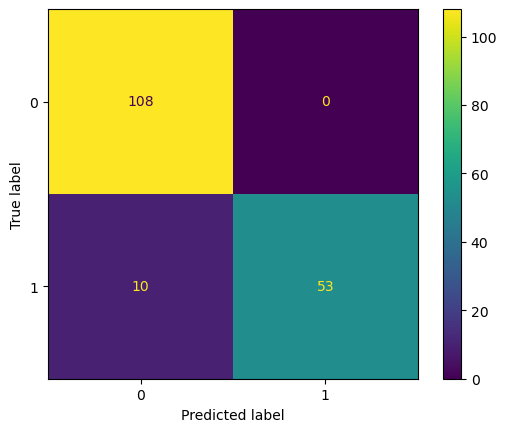

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=clf.classes_)
disp.plot()
plt.show()